# PTT版上的科技業求職與職涯討論分析

第 18 組：M144020003 莊雅筑、M144020005 胡新容、M144020009 劉芊妤、M144020018 陳孝杰

影片連結：https://youtu.be/Lg0gFQZsG5w

## A. 動機和分析目的
科技業是現今求職的熱門領域之一，不論是台灣企業或是外商都吸引了眾多求職者關注。  
由於PTT板上也有許多相關討論，因此我們希望透過分析PTT上的討論來分析台灣科技業求職者最關心的職涯議題。

本專案將透過情緒分析、主題分析、社群網路分析來探討不同科技公司在PTT論壇上的品牌聲量與形象：
1. 情緒分析：觀察各公司在 PTT 上的評價偏正面還是負面
2. 主題分析：分析各公司在 PTT 上常被討論的主題
3. 社群網路分析：觀察各公司與職場議題間的關係

## B. 資料來源
使用 TarFlow 蒐集 PTT Tech_Job 討論版上的文章
- 關鍵字：台積電、TSMC、聯發科、MTK、聯詠、瑞昱、Realtek、群聯、Phison、鴻海、廣達、緯創、仁寶、華碩、和碩、友達、日月光、世界先進、美光、Micron、Google、NVIDIA、AMD、ASML
- 時間： 2025/06-2026/06
- 資料筆數：約 690 篇文章
- 欄位說明：  
包含以下 11 個欄位：
+ `system_id`: 系統編號
+ `artUrl`：文章網址
+ `artTitle`：文章標題
+ `artDate`：文章日期
+ `artPoster`：發文者
+ `artCatagory`：文章類別
+ `artContent`：文章內容
+ `artComment`：文章評論
+ `e_ip`：發文或推文者的 IP 位址
+ `insertedDate`：插入日期
+ `dataSource`：資料來源



## C. 分析資料(包括文字資料和社會網絡資料)

大綱：
1. 資料前處理
2. 情緒分析：觀察各公司在 PTT 上的評價偏正面還是負面
3. 主題分析：分析各公司在 PTT 上常被討論的主題
4. 社群網路分析：觀察各公司與職場議題間的關係

##  情緒分析

1. 資料讀取與前處理
    - 1.1 中文斷句、斷詞
    - 1.2 移除停用字&繪製詞頻長條圖、文字雲
2. 利用 LIWC 進行情緒分析
    - 2.1 正負向情緒詞彙頻率折線圖
    - 2.2 正負向情緒詞彙比例折線圖
    - 2.3 正負文章數趨勢折線圖
3. 利用SnowNLP進行情緒分析


In [1]:
import pandas as pd
import jieba
import jieba.analyse
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import Colormap
from ckiptagger import data_utils, construct_dictionary, WS, POS, NER
import time
%matplotlib inline


c:\Users\acer\anaconda3\envs\practice\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### 1.1 中文斷句、斷詞

In [46]:
# 設定文字雲中文字體路徑
font_path = "raw_data/SourceHanSansTW-Regular.otf"

# 設定圖的字體大小
plt.rcParams['font.size'] = 14

# 1) 將字體檔案加入到 matplotlib 的字體庫
fm.fontManager.addfont(font_path)

# 2) 建立 FontProperties 物件
fprop = fm.FontProperties(fname=font_path)

# 3) 設定整體的 font.family 為此字體
plt.rcParams['font.family'] = fprop.get_name()
df = pd.read_csv("sna2026s_2_12bbceacc3_4.csv")

clear_df = df.copy()

# 將 artDate 轉換為 datetime 格式，並只保留日期部分
clear_df["artDate"] = pd.to_datetime(clear_df["artDate"])
clear_df['artDate'] = clear_df['artDate'].dt.date 

#去除文章內容為空值的筆數
clear_df.dropna(subset = ['artContent'], axis=0, how='any', inplace=True)

# 新增 sentence 欄位：先把跳脫字元換回換行，再做清理
clear_df['sentence'] = clear_df['artContent'].str.replace(r'\\n', '\n', regex=True)
clear_df['sentence'] = clear_df['sentence'].str.replace(r'\n\n', '。', regex=True)
clear_df['sentence'] = clear_df['sentence'].str.replace(r'\n', '', regex=True)


#移除內文中的網址
clear_df['sentence'] = clear_df['sentence'].replace(r'http\S+', '', regex=True).replace(r'www\S+', '', regex=True)

clear_df['sentence'] = clear_df['sentence'].str.split("[,，。！!？?]{1,}")

sent_df = clear_df.explode('sentence').reset_index(drop=True)

# 參考網址：https://raw.githubusercontent.com/ldkrsi/jieba-zh_TW/master/jieba/dict.txt
jieba.set_dictionary('dict/dict.txt')

#去除句子中除了字母、數字、空白字符以外的符號
sent_df['sentence'] = sent_df['sentence'].str.replace(r'[^\w\s]+', '', regex=True).astype(str)

# 把長度小於1的sentence刪掉
sent_df = sent_df[sent_df["sentence"].str.len() > 1]

word_df = sent_df.assign(word = sent_df['sentence'].apply(jieba.lcut)).explode('word').drop(['sentence'], axis=1)

# 去除空值
word_df = word_df.dropna(subset=['word'])

# word_df = word_df.loc[word_df['word'].str.len() > 1]

word_df.head(5)

Building prefix dict from c:\Users\acer\Desktop\中山\114下\社群媒體分析\期末專案\dict\dict.txt ...
Loading model from cache C:\Users\acer\AppData\Local\Temp\jieba.ue2a6870db884a4fad1b069715233c59c.cache
Loading model cost 0.524 seconds.
Prefix dict has been built successfully.


,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip,insertedDate,dataSource,word
0,1,https://www.ptt.cc/bbs/Tech_Job/M.1750216576.A...,[新聞]AI裁員潮來了？亞馬遜CEO警告未來數年,2025-06-18,baddaddy,Tech_Job,原文標題：\nAI 裁員潮來了？亞馬遜 CEO 警告未來數年人力將減少\n\n日期來源：\n...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""xvited945"", ...",49.216.161.54,2025-06-19 01:37:44,ptt,原文
0,1,https://www.ptt.cc/bbs/Tech_Job/M.1750216576.A...,[新聞]AI裁員潮來了？亞馬遜CEO警告未來數年,2025-06-18,baddaddy,Tech_Job,原文標題：\nAI 裁員潮來了？亞馬遜 CEO 警告未來數年人力將減少\n\n日期來源：\n...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""xvited945"", ...",49.216.161.54,2025-06-19 01:37:44,ptt,標題
0,1,https://www.ptt.cc/bbs/Tech_Job/M.1750216576.A...,[新聞]AI裁員潮來了？亞馬遜CEO警告未來數年,2025-06-18,baddaddy,Tech_Job,原文標題：\nAI 裁員潮來了？亞馬遜 CEO 警告未來數年人力將減少\n\n日期來源：\n...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""xvited945"", ...",49.216.161.54,2025-06-19 01:37:44,ptt,AI
0,1,https://www.ptt.cc/bbs/Tech_Job/M.1750216576.A...,[新聞]AI裁員潮來了？亞馬遜CEO警告未來數年,2025-06-18,baddaddy,Tech_Job,原文標題：\nAI 裁員潮來了？亞馬遜 CEO 警告未來數年人力將減少\n\n日期來源：\n...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""xvited945"", ...",49.216.161.54,2025-06-19 01:37:44,ptt,
0,1,https://www.ptt.cc/bbs/Tech_Job/M.1750216576.A...,[新聞]AI裁員潮來了？亞馬遜CEO警告未來數年,2025-06-18,baddaddy,Tech_Job,原文標題：\nAI 裁員潮來了？亞馬遜 CEO 警告未來數年人力將減少\n\n日期來源：\n...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""xvited945"", ...",49.216.161.54,2025-06-19 01:37:44,ptt,裁員


### 1.2 移除停用字&繪製詞頻長條圖、文字雲

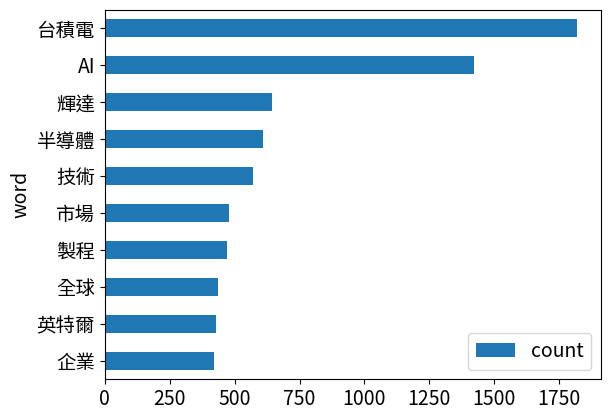

[(('人工', '智慧'), 141), (('先進', '製程'), 138), (('晶圓', '代工'), 119), (('奈米', '製程'), 112), (('台積電', '奈米'), 70), (('智慧', 'AI'), 64), (('先進', '封裝'), 63), (('報導', '台積電'), 62), (('綜合', '報導'), 60), (('輝達', 'NVIDIA'), 59), (('台積電', '2330'), 55), (('製程', '技術'), 54), (('基礎', '設施'), 53), (('on', 'my'), 48), (('競爭', '對手'), 48), (('資本', '支出'), 47), (('from', 'JPTT'), 46), (('JPTT', 'on'), 46), (('總統', '川普'), 44), (('川普', '政府'), 43)]


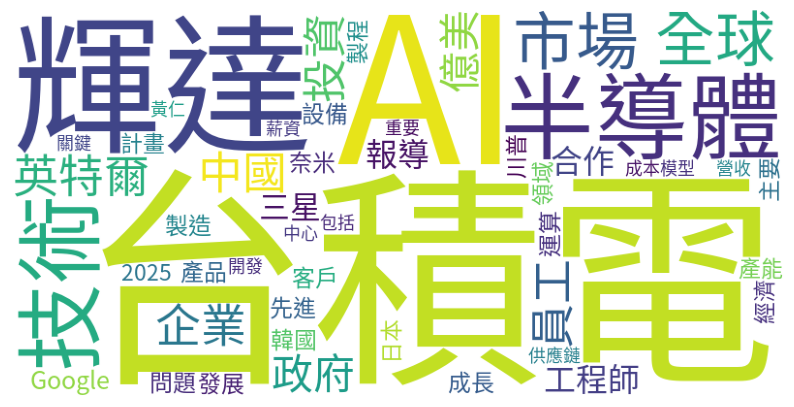

In [47]:

freq_df = word_df['word'].value_counts().reset_index(name='count')
word_df = word_df.loc[word_df['word'].str.len() > 1]

with open('dict/stopwords.txt', 'r', encoding='utf-8') as f:
    stopwords = [line.strip() for line in f.readlines()]

# 手動加入停用字，直接在這裡與外部停用字合併
stopwords_manual = [
    "知道", "現在", "一堆", "本來", "一直", "看到", "目前", "不用", "直接", "明年", "10", "這種", "一點", "根本", "表示", "反正", "繼續", "好像", "好了", "去年", "未來", "需要", "使用", "之後", "太多", "今天", "回來", "機會", "增加", 
    "樓上", "感覺", "會不會", "工作", "一年", "選擇", "加入", "更多", "考慮", "聽到", "預計", "空間", "不可能", "今年", "時間", "經營", "需求", "以後", "能力", "當初", "原文", "不發", "幾年", "至少", "過去", "最後", 
    "有沒有", "還在", "準備", "小時", "以前", "位置", "持續", "提供", "幹嘛", "認為", "標題", "有什麼", "幾個", "看看", "14", 
    "網路", "討論", "重點", "變成", "系統", "裡面", "要不要", "只能", "來源", "這麼多", "尤其", "規模", "事情", "完全", 
    "原來", "條件", "最近", "指出", "決定", "一次", "地方", "連結", "每週", "代表", "關係", "發現", "造成", "遇到", "日期", "謝謝", "15", "引述", "相關", "內部", "銘言", "XD","笑死","希望","資方","新聞", "客人","下去","那麼多","XDD","網友","理由", 
    "分享","完成","聽說","情況","反串","設計","有夠","每年"
]
stopwords.extend(stopwords_manual)

# 過濾停用字
noStop_df = word_df[~word_df['word'].isin(stopwords)]

# 初步繪製長條圖觀察
freq_df_nostop = noStop_df['word'].value_counts().reset_index(name='count')
freq_df_nostop.head(10).plot.barh(x='word', y='count').invert_yaxis()
plt.show()

# --- 2. Bigrams 探索 ---
tokens = noStop_df['word'].tolist()
bigrams = Counter(zip(tokens[:-1], tokens[1:]))
print(bigrams.most_common(20))

# --- 3. 加入自定義詞典並重新斷詞 ---
custom_words = ['人工智慧', '先進製程', '晶圓代工', '奈米製程', '智慧AI', '綜合報導', '製程技術', '基礎設施', '競爭對手']
for word in custom_words:
    jieba.add_word(word)

# sent_df 是還沒斷詞過的 df，重新斷詞 (這裡刪除了重複的區塊)
word_df_updated = sent_df.assign(word=sent_df['sentence'].apply(jieba.lcut)).explode('word').drop(['sentence'], axis=1)

# 把長度小於等於 1 的 row 刪掉
word_df_updated = word_df_updated.loc[word_df_updated['word'].str.len() > 1]

# 去除停用字
nostop_df_updated = word_df_updated[~word_df_updated['word'].isin(stopwords)]

# 計算最終詞頻
freq_df_updated = nostop_df_updated['word'].value_counts().reset_index(name='count')

# --- 4. 繪製最終文字雲 ---
# 修正：這裡改用 updated 版本的資料！
freq_dict_updated = freq_df_updated.set_index('word')['count'].to_dict()

# 繪製文字雲
# 確保 font_path 變數在前面有正確宣告
wordcloud_updated = WordCloud(background_color='white', width=800, height=400, font_path=font_path, max_words=50)
wordcloud_updated.generate_from_frequencies(freq_dict_updated)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud_updated)
plt.axis('off')
plt.show()

In [48]:
nostop_df_updated.to_csv("raw_data/clean_data.csv", encoding = 'utf-8',index = False)

### 2.1 正負向情緒詞彙頻率折線圖
利用 LIWC 進行情緒分析    
比對文章內的詞彙與 LIWC 字典，統計出文字中包含多少「正向情緒」或「負向情緒」的字眼   
畫出文集中，正向（positive）與負向（negative）情緒的折線圖

合併 LIWC 字典...
計算正負向詞彙頻率...

分析結果預覽：
       artDate sentiments  size
3   2025-06-18   negative    14
4   2025-06-18   positive    31
8   2025-06-19   negative    14
9   2025-06-19   positive    10
14  2025-06-20   negative     6
15  2025-06-20   positive    18
20  2025-06-21   negative    36
21  2025-06-21   positive    32
26  2025-06-22   negative    21
27  2025-06-22   positive    16


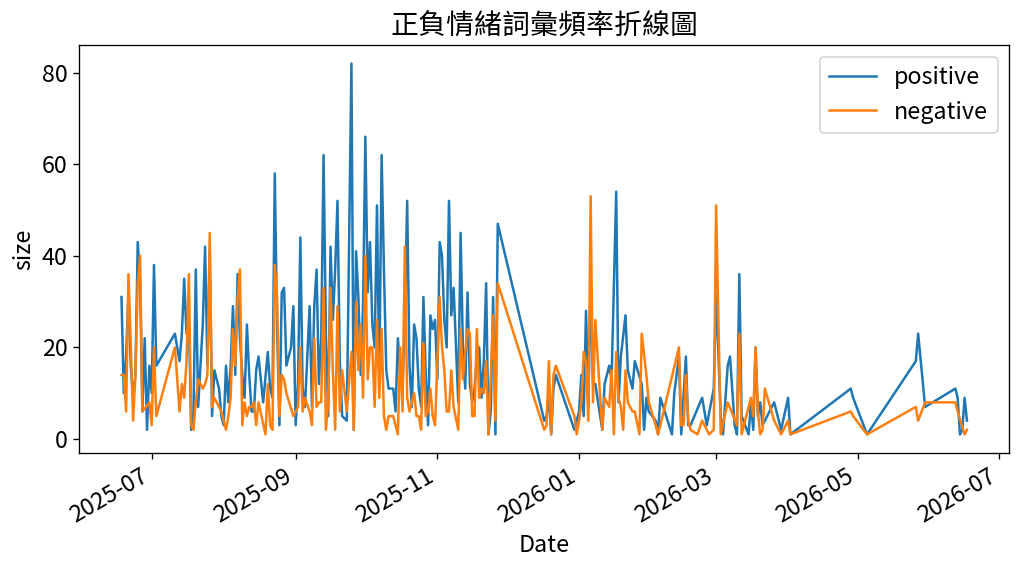

In [54]:
# # 讀取情緒字典
# liwc_dict = pd.read_csv("./dict/liwc/LIWC_CH.csv")
# liwc_dict = liwc_dict.rename(columns={'name': 'word', "class": 'sentiments'})
# ptt_liwc_df = pd.merge(nostop_df_updated[["artUrl", "artDate", "artTitle", "artContent", "word"]], liwc_dict, how="left")
# sentiment_count = pd.DataFrame(
#     ptt_liwc_df.groupby(["artDate", "sentiments"]).size()
# ).reset_index()

# mask = (sentiment_count['sentiments'] == "positive") | (sentiment_count['sentiments'] == "negative")
# sentiment_count = sentiment_count.loc[mask]

# sentiment_count = sentiment_count.rename(columns={0: "size"})
# sentiment_count = sentiment_count.sort_values(["artDate"])
# colors = ["tab:blue", "tab:orange"]
# pos = sentiment_count[sentiment_count["sentiments"] == "positive"]
# neg = sentiment_count[sentiment_count["sentiments"] == "negative"]

# # fig, ax = plt.subplots(figsize = (6,4), dpi = 150) # 也可以在該圖設定參數
# fig, ax = plt.subplots()

# ax.plot(pos["artDate"], pos["size"], color=colors[0], label="positive")
# ax.plot(neg["artDate"], neg["size"], color=colors[1], label="negative")

# plt.xlabel("artDate")
# # plt.ylabel('size')
# ax.legend(loc="upper right")
# fig.autofmt_xdate()
# plt.title("正負情緒詞彙頻率折線圖", fontproperties=fprop)  # 記得加上才能顯示中文
# plt.show()
# 3. 準備 LIWC 字典並進行合併
# ==========================================
print("合併 LIWC 字典...")
# 讀取 CSV 格式的 LIWC 字典，並重新命名欄位以利合併
liwc_dict = pd.read_csv("./dict/liwc/LIWC_CH.csv")
liwc_dict = liwc_dict.rename(columns={'name': 'word', "class": 'sentiments'})

# 將斷詞結果與 LIWC 字典進行 Left Merge
# 此處保留了系統 ID 或日期等欄位，以利後續群組計算
ptt_liwc_df = pd.merge(noStop_df[["artUrl","artDate", "artTitle", "artContent", "word"]], liwc_dict, on="word", how="left")


# ==========================================
# 4. 計算情緒詞彙頻率
# ==========================================
print("計算正負向詞彙頻率...")
# 透過 groupby 計算每天的正負向詞彙數量
sentiment_count = pd.DataFrame(
    ptt_liwc_df.groupby(["artDate", "sentiments"]).size()
).reset_index()

# 篩選出 sentiments 標註為 positive 或 negative 的資料
mask = (sentiment_count['sentiments'] == "positive") | (sentiment_count['sentiments'] == "negative")
sentiment_count = sentiment_count.loc[mask]

# 重新命名計算結果的欄位為 size 並排序
sentiment_count = sentiment_count.rename(columns={0: "size"})
sentiment_count = sentiment_count.sort_values(["artDate"])

print("\n分析結果預覽：")
print(sentiment_count.head(10))


# ==========================================
# 5. 情緒分析視覺化 ( Matplotlib 物件導向樣式 )
# ==========================================
sentiment_count['artDate'] = pd.to_datetime(sentiment_count['artDate'])

# 為了確保線條是由左至右畫過去，根據日期做一次最終排序
sentiment_count = sentiment_count.sort_values(by='artDate')

# 定義顏色與資料分組
colors = ["tab:blue", "tab:orange"]
pos = sentiment_count[sentiment_count["sentiments"] == "positive"]
neg = sentiment_count[sentiment_count["sentiments"] == "negative"]

# 建立畫布與軸物件
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)

# 繪製折線 (現在 artDate 已經是真正的時間格式了！)
ax.plot(pos["artDate"], pos["size"], color=colors[0]) 
ax.plot(neg["artDate"], neg["size"], color=colors[1])

# 設定 X 軸與 Y 軸標籤
plt.xlabel("Date")
plt.ylabel("size") 

# 設定圖例
ax.legend(["positive", "negative"], loc="upper right")

# 自動調整 X 軸日期標籤的角度，Matplotlib 也會自動幫你精簡顯示的日期刻度
fig.autofmt_xdate()

# 設定標題 
plt.title("正負情緒詞彙頻率折線圖") 

# 顯示圖表
plt.show()



正在繪製正負情緒詞彙頻率與 7 天移動平均折線圖...


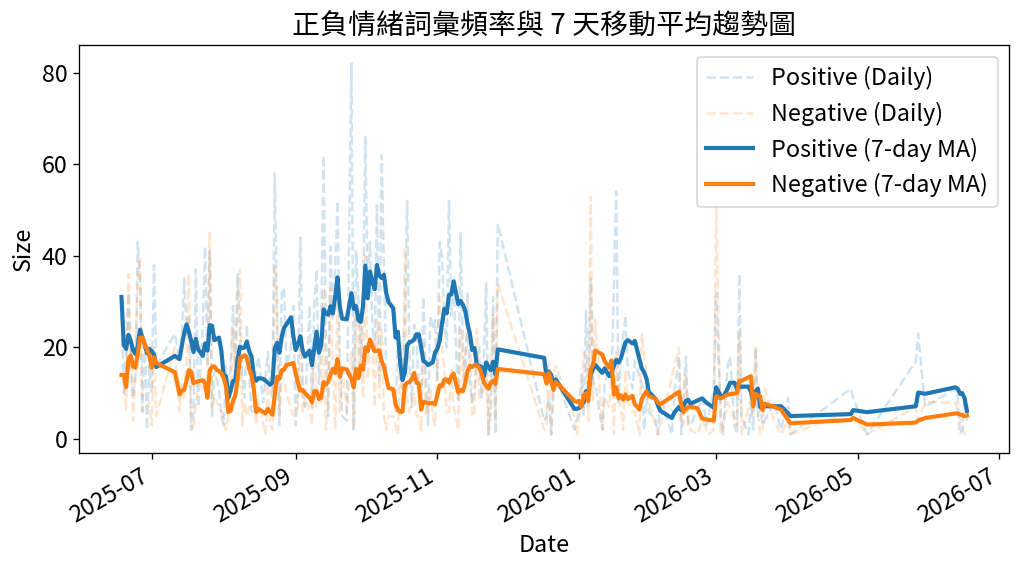

In [56]:
# ==========================================
# 5. 情緒分析視覺化 (加入 7 天移動平均線)
# ==========================================
print("正在繪製正負情緒詞彙頻率與 7 天移動平均折線圖...")

# 建議先確保日期為 datetime 格式
sentiment_count['artDate'] = pd.to_datetime(sentiment_count['artDate'])

colors = ["tab:blue", "tab:orange"]
pos = sentiment_count[sentiment_count["sentiments"] == "positive"]
neg = sentiment_count[sentiment_count["sentiments"] == "negative"]

# 建立畫布
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)

# 將移動平均的天數改為 7 天
rolling_days = 7

# 1. 畫出「原始數據」 (調低透明度當作背景)
ax.plot(pos["artDate"], pos["size"], color=colors[0], alpha=0.2, linestyle='--') 
ax.plot(neg["artDate"], neg["size"], color=colors[1], alpha=0.2, linestyle='--')

# 2. 畫出「7 天移動平均線」
ax.plot(pos["artDate"], pos['size'].rolling(rolling_days, min_periods=1).mean(), color=colors[0], linewidth=2.5)
ax.plot(neg["artDate"], neg["size"].rolling(rolling_days, min_periods=1).mean(), color=colors[1], linewidth=2.5)

plt.xlabel("Date")
plt.ylabel("Size")
ax.legend(["Positive (Daily)", "Negative (Daily)", "Positive (7-day MA)", "Negative (7-day MA)"], loc="upper right")
fig.autofmt_xdate()
plt.title("正負情緒詞彙頻率與 7 天移動平均趨勢圖")

plt.show()

分析結果與解釋:     
- 討論熱度主導了情緒詞彙的增減（走勢高度相關：   
  圖中的正向（藍線）與負向（橘線）情緒詞彙走勢幾乎完全一致（同升同降）。代表當天情緒詞彙數量的多寡，主要是受到當日文章總量或討論熱度的影響。討論量大時，無論正向或負向的詞彙都會同步增加。   
- 整體文本情緒偏向正面： 在圖表上的絕大多數時間點，藍線（正向）的數值都穩定高於橘線（負向）。這表示在您的這批資料中，正向詞彙的使用頻率大於負向詞彙，整體的討論氛圍或文章語氣相對偏向正面。

### 2.2 正負向情緒詞彙比例折線圖

Text(0.5, 1.0, '正負情緒比例折線圖')

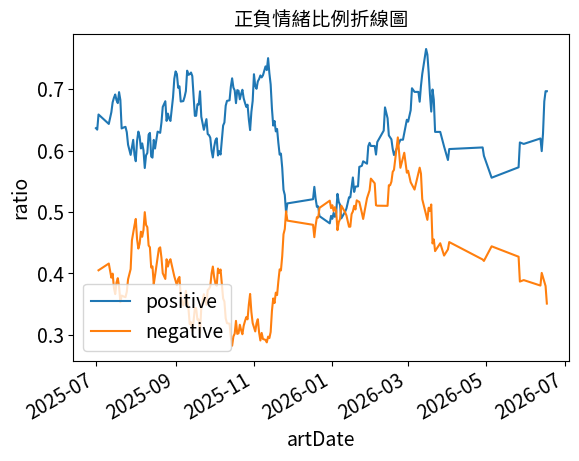

In [57]:
sentiment_count = sentiment_count.assign(
    ratio=sentiment_count.groupby("artDate")["size"].transform(lambda n: n / n.sum())
)
pos = sentiment_count[sentiment_count["sentiments"] == "positive"]
neg = sentiment_count[sentiment_count["sentiments"] == "negative"]

fig, ax = plt.subplots()

rolling_days = 14
ax.plot(pos["artDate"], pos["ratio"].rolling(rolling_days).mean(), color=colors[0])
ax.plot(neg["artDate"], neg["ratio"].rolling(rolling_days).mean(), color=colors[1])

plt.xlabel("artDate")
plt.ylabel("ratio")
ax.legend(["positive", "negative"], loc="lower left")
fig.autofmt_xdate()
plt.title("正負情緒比例折線圖", fontproperties=fprop)

### 2.3 正負文章數趨勢折線圖

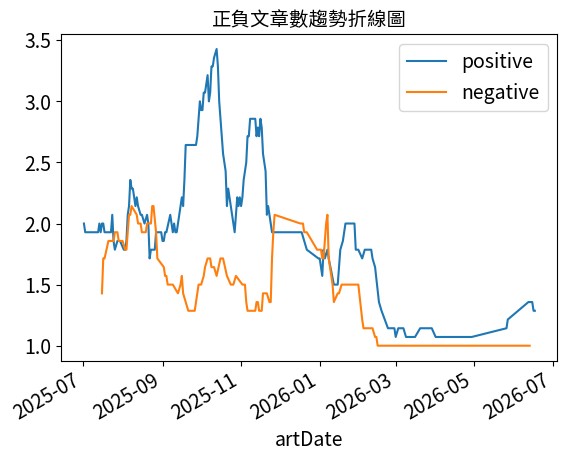

In [58]:
sentiment_count_by_article = pd.DataFrame(
    ptt_liwc_df.groupby(["artUrl", "sentiments"]).size()
).reset_index()
sentiment_count_by_article = sentiment_count_by_article.rename(columns={0: "size"})
#用pivot把df的sentiments拆成col
ptt_sentiment_value_by_article = (
    sentiment_count_by_article.pivot_table(
        index="artUrl", columns="sentiments", values="size", fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
)
ptt_sentiment_value_by_article["sentiment_value"] = (
    ptt_sentiment_value_by_article["positive"]
    - ptt_sentiment_value_by_article["negative"]
)
#根據分數+上class欄位
ptt_sentiment_value_by_article['sentiment_class'] = ptt_sentiment_value_by_article['sentiment_value'].apply(lambda x: "正向" if x > 0 else "負向" )

clear_df_sentiment = pd.merge(df, ptt_sentiment_value_by_article[['artUrl', 'sentiment_class']], how="left")
clear_df_sentiment["artDate"] = pd.to_datetime(clear_df_sentiment["artDate"])
clear_df_sentiment['artDate'] = clear_df_sentiment['artDate'].dt.date

sentiment_art_count = pd.DataFrame(
    clear_df_sentiment.groupby(["artDate", "sentiment_class"]).size()
).reset_index()
sentiment_art_count = sentiment_art_count.rename(columns={0: "size"})
sentiment_art_count = sentiment_art_count.sort_values(["artDate"])

colors = ["tab:blue", "tab:orange"]
pos = sentiment_art_count[sentiment_art_count["sentiment_class"] == "正向"]
neg = sentiment_art_count[sentiment_art_count["sentiment_class"] == "負向"]

# fig, ax = plt.subplots(figsize = (6,4), dpi = 150) # 也可以在該圖設定參數
fig, ax = plt.subplots()

# 使用 Series.rolling().mean() 來產生 14 天平均
rolling_days = 14
ax.plot(pos["artDate"], pos['size'].rolling(rolling_days).mean(), color=colors[0])
ax.plot(neg["artDate"], neg["size"].rolling(rolling_days).mean(), color=colors[1])
# ax.plot(pos["artDate"], pos['size'], color=colors[0])
# ax.plot(neg["artDate"], neg["size"], color=colors[1])

plt.xlabel("artDate")
# plt.ylabel('size')
ax.legend(["positive", "negative"], loc="upper right")
fig.autofmt_xdate()
plt.title("正負文章數趨勢折線圖", fontproperties=fprop)  # 記得加上才能顯示中文
plt.show()

分析結果與解釋:   
- 階段一：聲量大爆發與樂觀期（2025 年 10 月 - 11 月）
    - 在先前的圖表中，這段時間「正向情緒比例」與「總討論文章數」都來到最高峰。從 CSV 資料可以看出，這段期間的輿論是被「全球 AI 榮景」與「科技股狂飆」所帶動的極度樂觀情緒。
    - 熱門關鍵字與事件：  
        1. NVIDIA 股票神話與溫馨話題： 最具代表性的一篇熱門新聞是《輝達員工被哈瑪斯囚738天 同事告知好消息：股票漲了》。內文不僅有獲釋的正面消息，鄉民更瘋狂討論 NVIDIA 股價在這兩年間飆漲了 4.5 倍，「還原起來應該已經可以退休了」。這種財富效應極大地推升了正向情緒。   
        2. 台積電與 ASML 訂單爆發： 新聞如《ASML示警明年中國需求大降 執行長和財務長說原委》（指出 AI 投資蓬勃發展，Q3 訂單超出預期）、《蘇姿丰對AI市場充滿信心 準備海放英特爾》等，都在強化「台灣半導體 / AI 供應鏈天下無敵」的敘事。   
- 階段二：輿論翻轉與負面交叉期（2025 年 12 月 - 2026 年 1 月）
    - 在圖表中，這段時間正向比例雪崩，負面情緒（橘線）首度超越正面情緒（藍線）。從 CSV 中我們發現，這段時間爆發了一系列與台積電（TSMC）相關的公關危機、勞資爭議與赴美擴廠的負面效應，導致輿論急轉直下。  
    - 引爆負面情緒的四大核心事件：
        1. 美國廠管理與跳槽危機： 討論區出現多篇《Re:[新聞]拿E2簽證台積電工程師想跳Intel》的熱門文章，以及《台積電美國擴廠利潤嚴重縮水近8倍 無奈2大因素難為了》的新聞。反映出大眾對於台積電赴美設廠的擔憂、工程師的不滿，以及對企業獲利縮水的悲觀看法。
        2. 高層叛將與洩密疑雲： 爆發了重大商業新聞《台積電提告羅唯仁 前研發副總林本堅拋2大看法：英特爾反陷危機》。台積電前高層轉戰競爭對手 Intel 遭提告，引發鄉民對於「核心技術外流」的強烈焦慮與負面討論。

### 3. 利用SnowNLP進行情緒分析


+ 情緒值在 0~1之間，代表負面到正面

進行 SnowNLP 分析...
正在整理每月情緒平均值...

分析結果預覽 (每月平均情緒分數)：
   artDate  sentimentValue
0  2025-06        0.598387
1  2025-07        0.599622
2  2025-08        0.576614
3  2025-09        0.627595
4  2025-10        0.619400
5  2025-11        0.614814
6  2025-12        0.647312
7  2026-01        0.598449
8  2026-02        0.540644
9  2026-03        0.639016


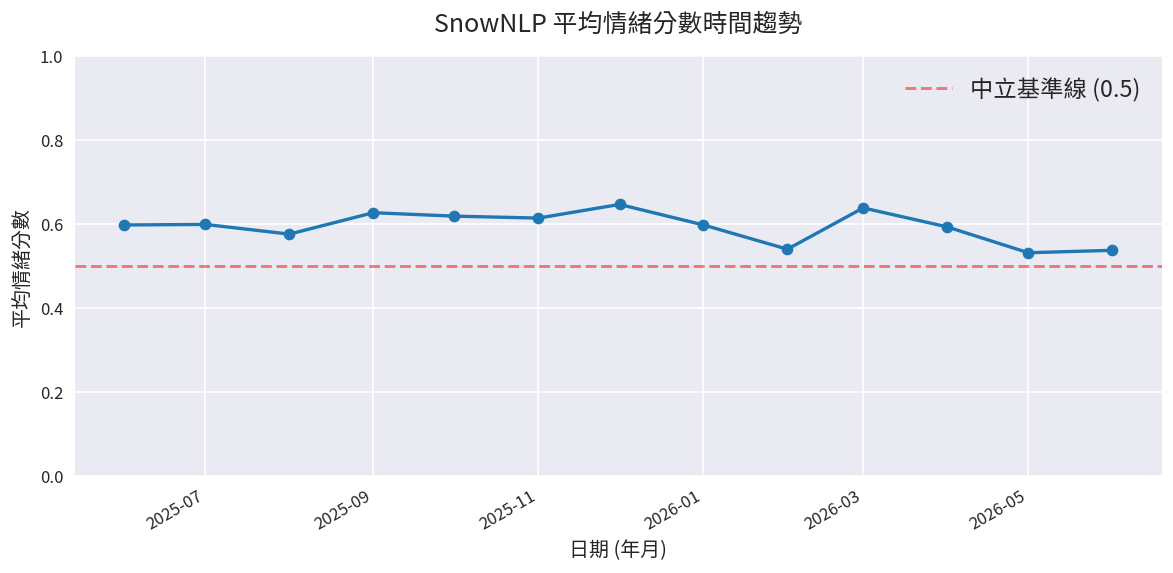

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
from opencc import OpenCC
from snownlp import SnowNLP  # 確保有 import SnowNLP
# import seaborn as sns      # 若後續要畫直方圖，記得 import seaborn

# ==========================================
# 1. SnowNLP 情緒分析與繁簡轉換
# ==========================================
print("進行 SnowNLP 分析...")
cc = OpenCC('t2s') # 繁體轉簡體以提高 SnowNLP 準確率

def get_snownlp_score(text):
    if not isinstance(text, str) or text.strip() == "":
        return 0.5
    try:
        simplified_text = cc.convert(text)
        s = SnowNLP(simplified_text)
        return s.sentiments 
    except Exception as e:
        return 0.5

# 計算每個句子的情緒分數
sent_df['sentimentValue'] = sent_df['sentence'].apply(get_snownlp_score)


# ==========================================
# 2. 整理每月情緒平均值
# ==========================================
print("正在整理每月情緒平均值...")
sentiment_date = sent_df[['artDate', 'sentimentValue']].copy()

# 將日期轉換為 DateTime 格式，並提取至「月份」(Period('M'))
sentiment_date['artDate'] = pd.to_datetime(sentiment_date['artDate'], errors='coerce').dt.to_period('M')
sentiment_date.dropna(subset=['artDate'], inplace=True)

# 透過 groupby 計算每個月的平均情緒分數
sentiment_count = sentiment_date.groupby(['artDate'])['sentimentValue'].mean().reset_index()

print("\n分析結果預覽 (每月平均情緒分數)：")
print(sentiment_count.head(10))


# ==========================================
# 3. 繪製每月平均情緒趨勢折線圖
# ==========================================
# 將 Period 轉回 Timestamp 以利畫圖
months = [period.to_timestamp() for period in sentiment_count['artDate']]   
y = sentiment_count['sentimentValue']

# 套用 seaborn 樣式
plt.style.use('seaborn-v0_8')

# 【修正】統一使用你之前載入的 font_path，確保跨平台不會出現亂碼
# 請確保 fprop 在前面的程式碼已經定義過： fprop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = fprop.get_name()
plt.rcParams['axes.unicode_minus'] = False # 正常顯示負號

# 建立圖表
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)

# 【修正】改用標準的 plot()，Matplotlib 會自動識別時間軸格式
ax.plot(months, y, linestyle='solid', color='tab:blue', marker='o', linewidth=2)

# 設定 Y 軸範圍在 0 到 1 之間 (SnowNLP 分數極限)
ax.set_ylim(0, 1)

# 加上 0.5 的中立基準線
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='中立基準線 (0.5)')

# 自動格式化 X 軸的日期顯示角度
fig.autofmt_xdate()

# 加上標題與標籤 (使用 fontproperties 確保安全)
ax.set_title('SnowNLP 平均情緒分數時間趨勢', fontproperties=fprop, fontsize=15, pad=15)
ax.set_xlabel('日期 (年月)', fontproperties=fprop, fontsize=12)
ax.set_ylabel('平均情緒分數', fontproperties=fprop, fontsize=12)

# 設定圖例
ax.legend(prop=fprop)

# 自動收緊版面配置
plt.tight_layout()

# 顯示圖表
plt.show()

分析結果與解釋:  
- 整體社群氛圍：長期偏向樂觀。從 2025 年 6 月到 2026 年 6 月這整整一年間，所有的藍色數據點全部都落在 0.5 的紅線之上。這代表在這段期間內，該論壇（例如科技版）的網民雖然會有情緒起伏，但整體的討論基調與發文用語，依然是偏向「正面、積極或滿意」的，並沒有出現長時間的集體悲觀。
- 情緒轉折點：情緒最低迷的月份 (約 2026-01)： 相對地，2026 年 1 月的分數掉到了這一年來的最低谷（大約 0.53 左右），幾乎快要碰到中立線。這意味著當月的討論氣氛明顯降溫、偏向負面或焦慮。這可能與年底考績出爐、外商科技大廠的年初裁員潮新聞，或是過年前的轉職焦慮感有關。
- 輿情的波動幅度：這條折線圖雖然上下跳動，但它的震盪區間大約維持在 0.53 到 0.72 之間。這代表討論的熱度與情緒屬於「正常的社群波動」。

## 結論
透過分析 2025 年 6 月至 2026 年 6 月期間 PTT Tech_Job 板上的討論文章，針對台灣科技業的品牌聲量與形象進行了深入探討。可歸納出以下:  

1. 整體社群氛圍：長期偏向樂觀與積極
儘管科技業面臨各種挑戰與波動，但在長達一年的分析期間內，論壇整體的平均情緒分數（透過 SnowNLP 分析）始終維持在 0.5 的基準線之上。代表 PTT 科技板網民的整體討論基調與發文用語，長期偏向「正面、積極或滿意」，並未出現長時間的集體悲觀現象。

2. 聲量與樂觀情緒最高峰（2025 年 10 月 - 11 月）：在這段期間，正向情緒比例與總討論文章數皆達到最高峰。輿論主要受到「全球 AI 榮景」與「科技股狂飆」的強烈帶動。

    - 財富效應與溫馨話題：NVIDIA 股價大幅飆漲（兩年間飆漲 4.5 倍）創造了巨大的財富效應，搭配輝達被哈瑪斯囚禁員工獲釋等具話題性的新聞，極大地推升了社群的正向情緒。

    - 供應鏈訂單爆發：台積電與 ASML 在 AI 相關的訂單超出預期，進一步強化了「台灣半導體與 AI 供應鏈天下無敵」的正面市場敘事。

3. 負面交叉期（2025 年 12 月 - 2026 年 1 月）：公關與管理危機
    - 隨著時間推移至年底與年初，正向情緒出現雪崩式下滑，負面情緒首度超越正面情緒。輿論翻轉主要源於台積電（TSMC）爆發的一系列公關危機與擴廠爭議。
    - 美國廠擴建與管理隱憂：大眾對於台積電赴美設廠導致的企業獲利縮水感到悲觀，同時工程師對管理制度的不滿以及跳槽競爭對手 Intel 的新聞，引發了強烈的負面討論。
    - 高層人事動盪與技術外流疑雲：台積電前高層轉戰 Intel 並遭提告的重大商業新聞，觸發了鄉民對於「核心技術外流」的強烈焦慮。

總結：
該期間內 PTT 科技板的求職與職涯討論，高度與「AI 產業的發展週期」及「指標性企業（如台積電、NVIDIA）的營運與人事動態」連動。雖然 AI 帶來的技術突破與股價紅利能輕易創造極度樂觀的社群氛圍，但跨國擴廠的挑戰、勞資爭議與核心技術保護等實務面的危機，依然是求職者與從業人員高度敏感且容易引發焦慮的核心議題。